<a href="https://colab.research.google.com/github/UbiOneKenobi/MNIST_project/blob/main/MNIST_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Classification Project

In this project we use the MNIST dataset to build a classifier capable of recognizing handwritten digits.

We will start with a simple binary classification problem: recognizing whether a digit is a **5** or not.

## 1. Load the MNIST dataset

`sklearn.datasets` generally provides three main types of functions:

- `fetch_*`: downloads real-world datasets, often from online repositories.
- `load_*`: loads small built-in datasets, mainly useful for learning and experimentation.
- `make_*`: generates artificial datasets, useful for testing and training.

We use `fetch_openml()` to download MNIST from OpenML.

`as_frame=False` makes Scikit-Learn return NumPy arrays instead of Pandas DataFrames.
For MNIST this is convenient because each image is represented by 784 numerical pixel values.

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

X, y = mnist.data, mnist.target

## 2. Inspect the dataset

Each MNIST image is 28 × 28 pixels.

Since the image is stored as a flat array, each observation contains:

28 × 28 = **784 features**

`X` contains the images, while `y` contains the corresponding digit labels.

In [2]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


## 3. Visualize a digit

To display an MNIST image, the 784-element array must be reshaped into its original 28 × 28 format.

The `plot_digit()` function performs this transformation and displays the image using Matplotlib.

In [3]:
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)

    # Display the image using a grayscale color map
    plt.imshow(image, cmap="binary")
    plt.axis("off")

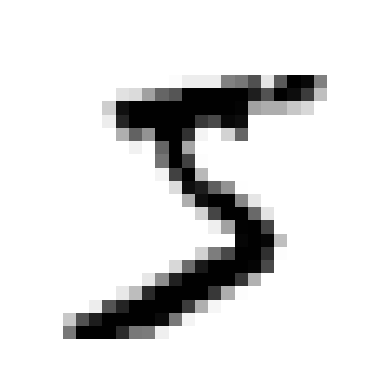

Label: 5


In [32]:
some_digit = X[0]

plot_digit(some_digit)
plt.show()

print("Label:", y[0])

## 4. Split the dataset

MNIST is already organized so that:

- the first 60,000 images are used for training;
- the last 10,000 images are used for testing.

We therefore separate the dataset accordingly.

In [5]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

## 5. Create a binary classification problem

Before trying to recognize all ten digits, we start with a simpler task:

> Is the digit a 5 or not?

We create new binary labels:

- `True` if the digit is 5;
- `False` otherwise.

In [6]:
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")

In [7]:
print(y_train[0])
print(y_train_5[0])

5
True


## 6. Train an SGD Classifier

We use `SGDClassifier`, a linear classification model trained using Stochastic Gradient Descent.

Instead of processing the entire training set at once during each optimization step, SGD updates the model incrementally using individual training instances.

This makes it suitable for relatively large datasets such as MNIST.

In [8]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

## 7. Make a prediction

Now that the classifier has been trained, we can ask it whether an image represents the digit 5.

Since this is a binary classifier, the prediction will be:

- `True` → the model predicts a 5;
- `False` → the model predicts another digit.

In [9]:
sgd_clf.predict([some_digit])

array([ True])

## 8. Evaluate the model using cross-validation

To evaluate the classifier more reliably, we use cross-validation.

With `cv=3`, the training set is divided into 3 folds.

The model is trained 3 separate times:

1. train on folds 2 and 3, validate on fold 1;
2. train on folds 1 and 3, validate on fold 2;
3. train on folds 1 and 2, validate on fold 3.

`scoring="accuracy"` measures the proportion of correctly classified instances.

In [10]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

scores

array([0.95035, 0.96035, 0.9604 ])

In [11]:
print("Accuracy for each fold:", scores)
print("Mean accuracy:", scores.mean())

Accuracy for each fold: [0.95035 0.96035 0.9604 ]
Mean accuracy: 0.9570333333333334


## 9. Using Dummy Model
The accuracy of the SDG model is over 95%, but let's first use the dummy model, which always guesses the most common class, to verify these results

In [12]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [13]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

## 10. Using Confusion
Since we saw trought the dummy model that accuracy as a scoring mechanism is not the best, we can use another model such as the confusion matrix

But first we are gonna use a cross validation prediction model, which instead of returning a score (cross_val_score) returns a boolean array of the predictions.

This array then will be compared to the actual results (y_train_5)
with the confusion matrix.

In [14]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [15]:
from sklearn.metrics import confusion_matrix
import pandas as pd
cm = confusion_matrix(y_train_5, y_train_pred)
cm_df = pd.DataFrame(
    cm,
    index=["REAL not 5", "REAL 5"],
    columns=["PRED not 5", "PRED 5"]
)
display(cm_df)

,PRED not 5,PRED 5
REAL not 5,53892,687
REAL 5,1891,3530


## 11. Precision and Recall
The confusion matrix is not the best to read without having some kind of metrics that can show faster and easier the results of our models.

The precision score is how often the results predicted as 5s were actually 5, while the recall_score represents the percentage of 5s detected (only 65%)

In [16]:
from sklearn.metrics import precision_score, recall_score

k = precision_score(y_train_5, y_train_pred)
l = recall_score(y_train_5, y_train_pred)
print(k)
print(l)

# 0.8370879772350012
# 0.6511713705958311

0.8370879772350012
0.6511713705958311


The f1_score is an harmonic mean of the recall_score and the precision_score

In [17]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred )

# 0.7325171197343847

0.7325171197343847

## 12. The Precision/Recall trade-off
In classification models, a value is classified as such based on a score, if the score is higher than a certain threshold then it returns True, otherwhise False.

To choose the right threshold we first need to analyze the scores that the SGD model gives and later create our own threshold.

In [18]:
y_scores = sgd_clf.decision_function([some_digit]) # some_digit = X[0]
y_scores #2164
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [19]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

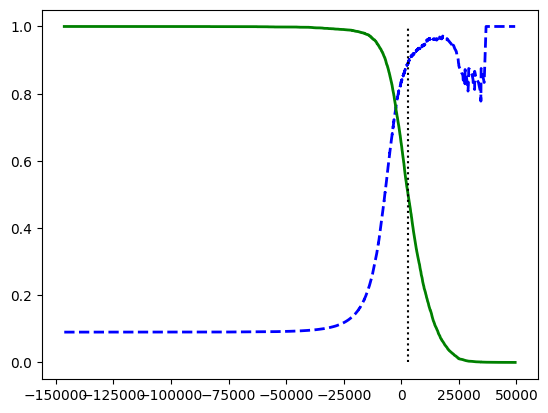

In [20]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

Let's try to aim for 90% of precision.

In [21]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [22]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_score(y_train_5, y_train_pred_90)


0.9000345901072293

In [23]:
recall_score(y_train_5, y_train_pred_90)


0.4799852425751706

## 13. The ROC Curve
The ROC curve plots the True Positive Rate against the False Positive Rate.

In [24]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

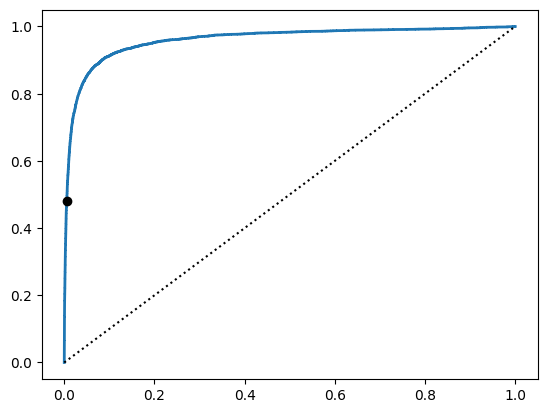

In [25]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax() # Find the ROC point corresponding to the threshold that achieves at least 90% precision
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.show()

The TPR (recall) gets higher as the FPR gets lower.

The dotted line represents a Random Classifier and the area below it is 0.5.

A perfect classifier would have an area of 1 so let's see how ours is doing.

In [26]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores) # 0.9604938554008616

np.float64(0.9604938554008616)

Let's now create a RandomForestClassifier to compare it to our SGDClassifier

In [27]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state = 42)

We can't use the decision_function() method in the randomforestclassifier because it doesn't have one but we can see the probability of each istance.

In [28]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")



In [29]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

## 14. Multiclass Classification
To handle multiple classes natively, we can use binary classifiers against each other (this is called one-versus-the-rest strategy).

We can instead train a binary classifier for every pair of digits (one to distinguish 0s and 2s and so on). This is the one-versus-one strategy.

This would result in training N x (N-1)/2 classifiers or 45 in the MNIST case, but since this dataset is small ( we are gonna be using only 2000 instances)

Let's try to use the SVC class with only 2000 instances.

In [30]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

SVC(random_state=42)

In [37]:
svm_clf.predict([some_digit])

array(['3'], dtype=object)

In [40]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

We noticed how sklearn decided autonomously wether to use a OvR or OvO classifier, but let's try to do it by ourselves with the OneVsRestClassifier.

In [43]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

ovr_clf.predict([some_digit])
len(ovr_clf.estimators_)

array(['5'], dtype='<U1')

Even tho we know we can't use the SDGClassifier with multiclass datasets because it's a binary model, let's try it.

In [45]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train[:2000], y_train[:2000])
sgd_clf.predict([some_digit])


array(['5'], dtype='<U1')

In [47]:
sgd_clf.decision_function([some_digit]).round(2)

array([[-1704540.27, -1683382.43, -2594122.51,  -145667.73, -3270741.37,
           -4883.95, -3420127.24, -1846510.17, -1328858.01, -2043246.17]])

The result is correct but the deicison function shows how the model is not confident at all.

Let's try to cross train it on the whole dataset.

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy" )

This shows that the accuracy is high, but could also be higher if we used Standard Scaler.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy" )